# Arkham Data Science Challenge

In [24]:
import requests as rq
import pandas as pd
import openpyxl
import time
from datetime import date, timedelta
import numpy as np
import matplotlib.pyplot as plt

## Task 1: Data extraction

In [4]:
nodos = pd.read_excel('catalogonodos.xlsx', header = 1)
nodos.columns

Index(['SISTEMA', 'CENTRO DE CONTROL REGIONAL', 'ZONA DE CARGA', 'CLAVE',
       'NOMBRE', 'NIVEL DE TENSIÓN (kV)', 'DIRECTAMENTE MODELADA',
       'INDIRECTAMENTE MODELADA', 'DIRECTAMENTE MODELADA.1',
       'INDIRECTAMENTE MODELADA.1', 'ZONA DE OPERACIÓN DE TRANSMISIÓN',
       'GERENCIA REGIONAL DE TRANSMISIÓN', 'ZONA DE DISTRIBUCIÓN',
       'GERENCIA DIVISIONAL DE DISTRIBUCIÓN',
       'CLAVE DE ENTIDAD FEDERATIVA (INEGI)', 'ENTIDAD FEDERATIVA (INEGI)',
       'CLAVE DE MUNICIPIO (INEGI)', 'MUNICIPIO (INEGI)',
       'REGION DE TRANSMISION'],
      dtype='str')

In [5]:
len(nodos)

2585

In [6]:
#True if ('Monclova' in nodos['ZONA DE CARGA'].unique()) else False
nodos['ZONA DE CARGA'].unique()

<StringArray>
[      'ENSENADA',       'MEXICALI',        'SANLUIS',        'TIJUANA',
      'No Aplica',   'CONSTITUCION',         'LA PAZ',      'LOS CABOS',
 'CENTRO ORIENTE',     'CENTRO SUR',
 ...
         'XALAPA',    'ZIHUATANEJO',       'CAMPECHE',         'CANCUN',
         'CARMEN',       'CHETUMAL',         'MERIDA',  'MOTUL TIZIMIN',
   'RIVIERA MAYA',          'TICUL']
Length: 109, dtype: str

In [7]:
nodos_mclv = nodos[nodos['ZONA DE CARGA'].str.lower() == 'monclova']
nodos_mclv_str = ','.join(nodos_mclv['CLAVE'])
nodos_mclv_str

'06AEO-115,06AHM-400,06FRO-115,06GRA-115,06MON-115,06MON-230,06RGS-115,06TKS-115,06XOC-115'

In [ ]:
sistema = 'SIN'
proceso = 'MDA'
lista_nodos = nodos_mclv_str
anio_ini = '2024'
mes_ini = '01'
dia_ini = '01'
anio_fin = '2024'
mes_fin = '01'
dia_fin = '02'
formato = 'JSON'

url = f'https://ws01.cenace.gob.mx:8082/SWPML/SIM/{sistema}/{proceso}/{lista_nodos}/{anio_ini}/{mes_ini}/{dia_ini}/{anio_fin}/{mes_fin}/{dia_fin}/{formato}'
respuesta = rq.get(url)

if respuesta.status_code == 200:
    
    # 3. Conviertes la respuesta directamente a un diccionario de Python
    datos_json = respuesta.json()
    
    # Aquí ya puedes acceder a datos_json['Resultados'] y procesarlos
    print(f"DAtos para el request a {url}")
    # 1. Load the in-memory JSON data directly
    df = pd.DataFrame(datos_json)

    # Save as CSV
    #df.to_csv("resultado.csv", index=False)
    df = df['Resultados']
    print(df)
else:
    print(f"Ups, error en el servidor: {respuesta.status_code}")

# 4. Haces una pequeña pausa antes de la siguiente vuelta del bucle
time.sleep(2)

DAtos para el request a https://ws01.cenace.gob.mx:8082/SWPML/SIM/SIN/MDA/06AEO-115,06AHM-400,06FRO-115,06GRA-115,06MON-115,06MON-230,06RGS-115,06TKS-115,06XOC-115/2024/01/01/2024/01/02/JSON
0    {'clv_nodo': '06AEO-115', 'Valores': [{'fecha'...
1    {'clv_nodo': '06AHM-400', 'Valores': [{'fecha'...
2    {'clv_nodo': '06FRO-115', 'Valores': [{'fecha'...
3    {'clv_nodo': '06GRA-115', 'Valores': [{'fecha'...
4    {'clv_nodo': '06MON-115', 'Valores': [{'fecha'...
5    {'clv_nodo': '06MON-230', 'Valores': [{'fecha'...
6    {'clv_nodo': '06RGS-115', 'Valores': [{'fecha'...
7    {'clv_nodo': '06TKS-115', 'Valores': [{'fecha'...
8    {'clv_nodo': '06XOC-115', 'Valores': [{'fecha'...
Name: Resultados, dtype: object


In [ ]:
def flattenData(form):
    flattenedRows = []
    for nodo in form['Resultados']:
        clave = nodo['clv_nodo']
        for valores in nodo['Valores']:
            valores['nodo'] = clave 
            flattenedRows.append(valores)

    return pd.DataFrame(flattenedRows)

In [10]:
flattenData(datos_json)

,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo
0,2024-01-01,1,279.92,370.71,-43.69,-47.1,06AEO-115
1,2024-01-01,2,279.21,311.75,-32.54,0,06AEO-115
2,2024-01-01,3,274.23,305.52,-31.28,0,06AEO-115
3,2024-01-01,4,264.01,294.23,-30.22,0,06AEO-115
4,2024-01-01,5,243.44,267.66,-24.22,0,06AEO-115
...,...,...,...,...,...,...,...
427,2024-01-02,20,594.32,649.19,-54.86,0,06XOC-115
428,2024-01-02,21,392.26,431.03,-38.77,0,06XOC-115
429,2024-01-02,22,592.27,646.27,-52.38,-1.62,06XOC-115
430,2024-01-02,23,490.33,535.61,-45.28,0,06XOC-115


In [19]:
def getRequestURLs(startDate, endDate, lista_nodos, sistema='SIN', proceso='MDA', formato='JSON'):
    URLlist = []
    current_date = startDate
    
    while current_date <= endDate: 
    
        chunk_end = current_date + timedelta(days=6)
        if chunk_end > endDate:
            chunk_end = endDate

        # .strftime("%Y/%m/%d") asegura el formato exacto que pide el CENACE
        f_ini = current_date.strftime("%Y/%m/%d")
        f_fin = chunk_end.strftime("%Y/%m/%d")
        
        url = f"https://ws01.cenace.gob.mx:8082/SWPML/SIM/{sistema}/{proceso}/{lista_nodos}/{f_ini}/{f_fin}/{formato}"

        URLlist.append(url)

        current_date = chunk_end + timedelta(days=1)
        
    return URLlist

In [23]:
urlList = getRequestURLs(date(2024,1,1), date(2025,6,30), nodos_mclv_str)
urlList

['https://ws01.cenace.gob.mx:8082/SWPML/SIM/SIN/MDA/06AEO-115,06AHM-400,06FRO-115,06GRA-115,06MON-115,06MON-230,06RGS-115,06TKS-115,06XOC-115/2024/01/01/2024/01/07/JSON',
 'https://ws01.cenace.gob.mx:8082/SWPML/SIM/SIN/MDA/06AEO-115,06AHM-400,06FRO-115,06GRA-115,06MON-115,06MON-230,06RGS-115,06TKS-115,06XOC-115/2024/01/08/2024/01/14/JSON',
 'https://ws01.cenace.gob.mx:8082/SWPML/SIM/SIN/MDA/06AEO-115,06AHM-400,06FRO-115,06GRA-115,06MON-115,06MON-230,06RGS-115,06TKS-115,06XOC-115/2024/01/15/2024/01/21/JSON',
 'https://ws01.cenace.gob.mx:8082/SWPML/SIM/SIN/MDA/06AEO-115,06AHM-400,06FRO-115,06GRA-115,06MON-115,06MON-230,06RGS-115,06TKS-115,06XOC-115/2024/01/22/2024/01/28/JSON',
 'https://ws01.cenace.gob.mx:8082/SWPML/SIM/SIN/MDA/06AEO-115,06AHM-400,06FRO-115,06GRA-115,06MON-115,06MON-230,06RGS-115,06TKS-115,06XOC-115/2024/01/29/2024/02/04/JSON',
 'https://ws01.cenace.gob.mx:8082/SWPML/SIM/SIN/MDA/06AEO-115,06AHM-400,06FRO-115,06GRA-115,06MON-115,06MON-230,06RGS-115,06TKS-115,06XOC-115/202

In [24]:
lista_chunks = []
for link in urlList:
    respuesta = rq.get(link)

    if respuesta.status_code == 200:
        rowsChunk = flattenData(respuesta.json())
        print(f"Datos para el request a {link[-30:]}")
        print(rowsChunk)
        lista_chunks.append(rowsChunk)
        
    else:
        print(f"Ups, error en el servidor: {respuesta.status_code}")

    time.sleep(2)

Datos para el request a 115/2024/01/01/2024/01/07/JSON
           fecha hora     pml pml_ene pml_per pml_cng       nodo
0     2024-01-01    1  279.92  370.71  -43.69   -47.1  06AEO-115
1     2024-01-01    2  279.21  311.75  -32.54       0  06AEO-115
2     2024-01-01    3  274.23  305.52  -31.28       0  06AEO-115
3     2024-01-01    4  264.01  294.23  -30.22       0  06AEO-115
4     2024-01-01    5  243.44  267.66  -24.22       0  06AEO-115
...          ...  ...     ...     ...     ...     ...        ...
1507  2024-01-07   20  483.26  603.07  -76.33  -43.48  06XOC-115
1508  2024-01-07   21  482.72  602.26   -75.5  -44.03  06XOC-115
1509  2024-01-07   22  458.49  581.47  -72.13  -50.85  06XOC-115
1510  2024-01-07   23  410.74  468.46  -57.72       0  06XOC-115
1511  2024-01-07   24  375.39  428.35  -52.95       0  06XOC-115

[1512 rows x 7 columns]
Datos para el request a 115/2024/01/08/2024/01/14/JSON
           fecha hora     pml  pml_ene  pml_per  pml_cng       nodo
0     2024-01-08 

In [ ]:
# dataframe consolidado
info = pd.concat(lista_chunks, ignore_index=True)

info.to_csv('monclova_pml_2024_2025.csv', index=False)

print(f"Filas totales recuperadas: {info.shape[0]}")
print(f"Columnas recuperadas: {info.shape[1]}")
info.head()

Filas totales recuperadas: 118152
Columnas recuperadas: 7


,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo
0,2024-01-01,1,279.92,370.71,-43.69,-47.1,06AEO-115
1,2024-01-01,2,279.21,311.75,-32.54,0,06AEO-115
2,2024-01-01,3,274.23,305.52,-31.28,0,06AEO-115
3,2024-01-01,4,264.01,294.23,-30.22,0,06AEO-115
4,2024-01-01,5,243.44,267.66,-24.22,0,06AEO-115


## Task 2: Modeling Tracks​

In [39]:
df = pd.read_csv('monclova_pml_2024_2025.csv')

df['fecha'] = pd.to_datetime(df['fecha'], format='%Y-%m-%d')
df['hora'] = df['hora'].astype(int) - 1
df['fecha_hora'] = df['fecha'] + pd.to_timedelta(df['hora'], unit='h')
df

,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo,fecha_hora
0,2024-01-01,0,279.92,370.71,-43.69,-47.10,06AEO-115,2024-01-01 00:00:00
1,2024-01-01,1,279.21,311.75,-32.54,0.00,06AEO-115,2024-01-01 01:00:00
2,2024-01-01,2,274.23,305.52,-31.28,0.00,06AEO-115,2024-01-01 02:00:00
3,2024-01-01,3,264.01,294.23,-30.22,0.00,06AEO-115,2024-01-01 03:00:00
4,2024-01-01,4,243.44,267.66,-24.22,0.00,06AEO-115,2024-01-01 04:00:00
...,...,...,...,...,...,...,...,...
118147,2025-06-30,19,670.23,697.67,-27.44,0.00,06XOC-115,2025-06-30 19:00:00
118148,2025-06-30,20,739.10,759.88,-20.78,0.00,06XOC-115,2025-06-30 20:00:00
118149,2025-06-30,21,672.48,685.42,-12.95,0.00,06XOC-115,2025-06-30 21:00:00
118150,2025-06-30,22,659.18,672.25,-13.08,0.00,06XOC-115,2025-06-30 22:00:00


In [9]:
df_nodo = df[df['nodo'] == '06AEO-115'].copy()
df_nodo = df.sort_values('fecha_hora').reset_index(drop=True)
df_nodo

,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo,fecha_hora
0,2024-01-01,0,279.92,370.71,-43.69,-47.10,06AEO-115,2024-01-01 00:00:00
1,2024-01-01,1,279.21,311.75,-32.54,0.00,06AEO-115,2024-01-01 01:00:00
2,2024-01-01,2,274.23,305.52,-31.28,0.00,06AEO-115,2024-01-01 02:00:00
3,2024-01-01,3,264.01,294.23,-30.22,0.00,06AEO-115,2024-01-01 03:00:00
4,2024-01-01,4,243.44,267.66,-24.22,0.00,06AEO-115,2024-01-01 04:00:00
...,...,...,...,...,...,...,...,...
13123,2025-06-30,19,670.21,697.67,-27.46,0.00,06AEO-115,2025-06-30 19:00:00
13124,2025-06-30,20,739.04,759.88,-20.84,0.00,06AEO-115,2025-06-30 20:00:00
13125,2025-06-30,21,672.44,685.42,-12.98,0.00,06AEO-115,2025-06-30 21:00:00
13126,2025-06-30,22,659.25,672.25,-13.00,0.00,06AEO-115,2025-06-30 22:00:00


In [13]:

df_nodo['pml'] = pd.to_numeric(df_nodo['pml'])

# --- Z-SCORE ---
# definimos nuestra ventana móvil: 7 días = 168 horas
ventana = 168
# calculamos el promedio y la desviación estándar de las últimas 168 horas
df_nodo['media_movil'] = df_nodo['pml'].rolling(window=ventana, min_periods=1).mean()
df_nodo['std_movil'] = df_nodo['pml'].rolling(window=ventana, min_periods=1).std()

# aplicamos la fórmula del Z-Score: (Valor actual - Media) / Desviación
# usamos np.where para evitar errores de división por cero si la std es 0
df_nodo['z_score'] = np.where(df_nodo['std_movil'] > 0, 
                              (df_nodo['pml'] - df_nodo['media_movil']) / df_nodo['std_movil'], 
                              0)

In [17]:
df_nodo[df_nodo['fecha'] == '2024-12-30']

,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo,fecha_hora,media_movil,std_movil,z_score
8736,2024-12-30,0,232.92,430.53,-33.95,-163.66,06AEO-115,2024-12-30 00:00:00,379.343155,137.113344,-1.067899
8737,2024-12-30,1,219.69,434.62,-38.44,-176.49,06AEO-115,2024-12-30 01:00:00,378.285298,137.657612,-1.152100
8738,2024-12-30,2,191.19,356.65,-33.31,-132.16,06AEO-115,2024-12-30 02:00:00,377.274405,138.406698,-1.344475
8739,2024-12-30,3,133.25,146.29,-13.04,0.00,06AEO-115,2024-12-30 03:00:00,376.002917,139.663248,-1.738130
8740,2024-12-30,4,0.00,0.00,0.00,0.00,06AEO-115,2024-12-30 04:00:00,373.928452,142.630794,-2.621653
8741,2024-12-30,5,0.00,0.00,0.00,0.00,06AEO-115,2024-12-30 05:00:00,371.553690,145.503879,-2.553566
8742,2024-12-30,6,182.32,367.33,-36.36,-148.65,06AEO-115,2024-12-30 06:00:00,370.046190,146.147093,-1.284502
8743,2024-12-30,7,218.65,431.96,-40.75,-172.57,06AEO-115,2024-12-30 07:00:00,368.646488,146.465860,-1.024105
8744,2024-12-30,8,204.61,440.48,-43.45,-192.43,06AEO-115,2024-12-30 08:00:00,367.217202,146.889944,-1.107000
8745,2024-12-30,9,28.36,447.20,-43.63,-375.21,06AEO-115,2024-12-30 09:00:00,364.993631,149.171179,-2.256694


In [18]:
# Nuestra regla de negocio: Si el valor absoluto de Z es mayor a 3, es una anomalía (1), si no, es normal (0)
df_nodo['es_anomalia'] = np.where(df_nodo['z_score'].abs() > 3, 1, 0)

# Vemos un resumen de cuántas anomalías detectó
print(f"Total de registros evaluados: {len(df_nodo)}")
print(f"Anomalías detectadas: {df_nodo['es_anomalia'].sum()}")

Total de registros evaluados: 13128
Anomalías detectadas: 382


In [19]:
df_nodo[df_nodo['es_anomalia']==1]

,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo,fecha_hora,media_movil,std_movil,z_score,es_anomalia
114,2024-01-05,18,937.12,1337.01,-109.61,-290.28,06AEO-115,2024-01-05 18:00:00,342.843478,154.715533,3.841092,1
115,2024-01-05,19,893.54,1072.64,-85.84,-93.26,06AEO-115,2024-01-05 19:00:00,347.590862,162.305628,3.363710,1
116,2024-01-05,20,895.67,1194.14,-95.48,-203.00,06AEO-115,2024-01-05 20:00:00,352.275299,169.361930,3.208482,1
360,2024-01-16,0,1239.94,1385.41,-145.47,0.00,06AEO-115,2024-01-16 00:00:00,487.140833,144.626206,5.205137,1
361,2024-01-16,1,1159.59,1281.73,-122.14,0.00,06AEO-115,2024-01-16 01:00:00,492.097976,153.120099,4.359271,1
...,...,...,...,...,...,...,...,...,...,...,...,...
12884,2025-06-20,20,1594.98,1610.73,-15.51,-0.25,06AEO-115,2025-06-20 20:00:00,663.187917,227.533645,4.095184,1
12885,2025-06-20,21,1872.90,1867.07,-41.28,47.11,06AEO-115,2025-06-20 21:00:00,667.633155,243.375052,4.952302,1
12908,2025-06-21,20,1690.42,454.08,-27.76,1264.10,06AEO-115,2025-06-21 20:00:00,679.597262,263.108784,3.841843,1
12980,2025-06-24,20,1772.74,1794.34,-21.32,-0.27,06AEO-115,2025-06-24 20:00:00,651.168690,263.496612,4.256492,1


In [21]:
df_nodo[df_nodo['fecha'] == '2024-01-05']

,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo,fecha_hora,media_movil,std_movil,z_score,es_anomalia
96,2024-01-05,0,599.89,654.37,-54.48,0.00,06AEO-115,2024-01-05 00:00:00,320.296289,145.373335,1.923281,0
97,2024-01-05,1,433.36,472.99,-39.63,0.00,06AEO-115,2024-01-05 01:00:00,321.450000,145.072325,0.771408,0
98,2024-01-05,2,413.71,448.63,-34.92,0.00,06AEO-115,2024-01-05 02:00:00,322.381919,144.627810,0.631470,0
99,2024-01-05,3,404.98,440.61,-35.63,0.00,06AEO-115,2024-01-05 03:00:00,323.207900,144.132380,0.567340,0
100,2024-01-05,4,401.24,437.25,-36.01,0.00,06AEO-115,2024-01-05 04:00:00,323.980495,143.619945,0.537944,0
101,2024-01-05,5,409.30,448.12,-38.83,0.00,06AEO-115,2024-01-05 05:00:00,324.816961,143.156665,0.590144,0
102,2024-01-05,6,434.00,475.30,-41.30,0.00,06AEO-115,2024-01-05 06:00:00,325.876990,142.858840,0.756852,0
103,2024-01-05,7,757.51,819.72,-62.21,0.00,06AEO-115,2024-01-05 07:00:00,330.027308,148.330442,2.881962,0
104,2024-01-05,8,429.78,471.01,-41.23,0.00,06AEO-115,2024-01-05 08:00:00,330.977333,147.936239,0.667873,0
105,2024-01-05,9,393.92,442.34,-48.42,0.00,06AEO-115,2024-01-05 09:00:00,331.571132,147.356968,0.423114,0


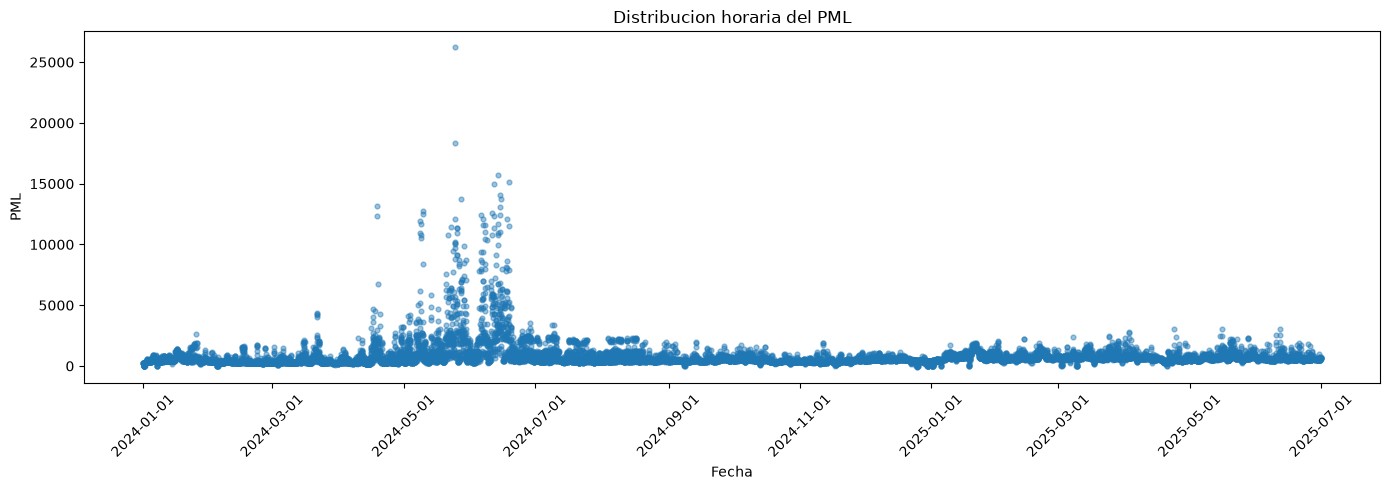

In [40]:
import matplotlib.dates as mdates

df_nodo['fecha'] = pd.to_datetime(df_nodo['fecha']).dt.date
df_nodo['fecha_hora'] = pd.to_datetime(df_nodo['fecha_hora'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(
    mdates.date2num(df_nodo['fecha_hora']),
    df_nodo['pml'],
    alpha=0.45,
    s=12
)
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_title('Distribucion horaria del PML')
ax.set_xlabel('Fecha')
ax.set_ylabel('PML')
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()

In [38]:
df_nodo[(df_nodo['fecha'].between(date(2024, 5, 1), date(2024, 7, 1))) & (df_nodo['es_anomalia'] == 1)]

,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo,fecha_hora,media_movil,std_movil,z_score,es_anomalia
2948,2024-05-02,20,4077.93,4228.58,-144.85,-5.80,06AEO-115,2024-05-02 20:00:00,795.479226,765.941566,4.285511,1
2966,2024-05-03,14,3622.63,2787.45,-126.94,962.12,06AEO-115,2024-05-03 14:00:00,921.098810,814.846565,3.315386,1
2971,2024-05-03,19,4184.40,4461.78,-250.94,-26.44,06AEO-115,2024-05-03 19:00:00,944.241429,853.736162,3.795269,1
2972,2024-05-03,20,3901.42,4179.02,-258.24,-19.36,06AEO-115,2024-05-03 20:00:00,953.438036,877.042731,3.361275,1
3067,2024-05-07,19,4996.64,5577.30,-202.72,-377.95,06AEO-115,2024-05-07 19:00:00,1049.382440,965.488172,4.088354,1
3087,2024-05-08,15,5162.37,4332.18,41.77,788.42,06AEO-115,2024-05-08 15:00:00,1210.497679,1041.420015,3.794696,1
3088,2024-05-08,16,6195.28,5165.42,51.26,978.61,06AEO-115,2024-05-08 16:00:00,1245.680357,1107.685695,4.468415,1
3089,2024-05-08,17,10930.57,10935.02,0.40,-4.85,06AEO-115,2024-05-08 17:00:00,1309.113274,1333.762889,7.213769,1
3091,2024-05-08,19,11906.51,12206.67,-335.51,35.36,06AEO-115,2024-05-08 19:00:00,1395.851905,1570.399312,6.692984,1
3092,2024-05-08,20,11649.27,11992.94,-375.55,31.89,06AEO-115,2024-05-08 20:00:00,1461.095238,1757.387612,5.797341,1


In [48]:
df_nodo[df_nodo['z_score'] ==df_nodo['z_score'].max()]

,fecha,hora,pml,pml_ene,pml_per,pml_cng,nodo,fecha_hora,media_movil,std_movil,z_score,es_anomalia
2611,2024-04-18,19,12356.23,12980.89,-500.18,-124.49,06AEO-115,2024-04-18 19:00:00,884.682857,1235.678952,9.283598,1
